# Install Required Libraries

In [1]:
!pip install -q imbalanced-learn xgboost

# Import Libraries

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import joblib
import warnings

warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


# Mount Google Drive

In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


# Load Dataset

In [4]:
file_path = "/content/drive/MyDrive/sensor-data.csv" # Assuming 'sensor-data.csv' is directly in MyDrive

df = pd.read_csv(file_path)

print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (1567, 592)


# Display First 5 Rows

In [5]:
df.head()

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


# Display Last 5 Rows

In [6]:
df.tail()

,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
1562,2008-10-16 15:13:00,2899.41,2464.36,2179.7333,3085.3781,1.4843,100.0,82.2467,0.1248,1.3424,...,203.1720,0.4988,0.0143,0.0039,2.8669,0.0068,0.0138,0.0047,203.1720,-1
1563,2008-10-16 20:49:00,3052.31,2522.55,2198.5667,1124.6595,0.8763,100.0,98.4689,0.1205,1.4333,...,NaN,0.4975,0.0131,0.0036,2.6238,0.0068,0.0138,0.0047,203.1720,-1
1564,2008-10-17 05:26:00,2978.81,2379.78,2206.3000,1110.4967,0.8236,100.0,99.4122,0.1208,NaN,...,43.5231,0.4987,0.0153,0.0041,3.0590,0.0197,0.0086,0.0025,43.5231,-1
1565,2008-10-17 06:01:00,2894.92,2532.01,2177.0333,1183.7287,1.5726,100.0,98.7978,0.1213,1.4622,...,93.4941,0.5004,0.0178,0.0038,3.5662,0.0262,0.0245,0.0075,93.4941,-1
1566,2008-10-17 06:07:00,2944.92,2450.76,2195.4444,2914.1792,1.5978,100.0,85.1011,0.1235,NaN,...,137.7844,0.4987,0.0181,0.0040,3.6275,0.0117,0.0162,0.0045,137.7844,-1


# Dataset Shape

In [7]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1567
Number of columns: 592


# Dataset Information

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 592 entries, Time to Pass/Fail
dtypes: float64(590), int64(1), object(1)
memory usage: 7.1+ MB


### Observation

The dataset contains multiple sensor-related attributes representing the semiconductor manufacturing process. The information shows the number of observations, features, data types, and non-null values. This helps in understanding the structure of the dataset before performing data preprocessing.

# Statistical Summary

In [9]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Time,1567,1534,2008-10-15 01:52:00,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,1561.0,NaN,NaN,NaN,3014.452896,73.621787,2743.24,2966.26,3011.49,3056.65,3356.35
1,1560.0,NaN,NaN,NaN,2495.850231,80.407705,2158.75,2452.2475,2499.405,2538.8225,2846.44
2,1553.0,NaN,NaN,NaN,2200.547318,29.513152,2060.66,2181.0444,2201.0667,2218.0555,2315.2667
3,1553.0,NaN,NaN,NaN,1396.376627,441.69164,0.0,1081.8758,1285.2144,1591.2235,3715.0417
...,...,...,...,...,...,...,...,...,...,...,...
586,1566.0,NaN,NaN,NaN,0.021458,0.012358,-0.0169,0.013425,0.0205,0.0276,0.1028
587,1566.0,NaN,NaN,NaN,0.016475,0.008808,0.0032,0.0106,0.0148,0.0203,0.0799
588,1566.0,NaN,NaN,NaN,0.005283,0.002867,0.001,0.0033,0.0046,0.0064,0.0286
589,1566.0,NaN,NaN,NaN,99.670066,93.891919,0.0,44.3686,71.9005,114.7497,737.3048


### Observation

The statistical summary provides important descriptive measures such as mean, median, standard deviation, minimum, maximum, and quartile values. The sensor features have different ranges and distributions, which indicates that feature scaling is required before applying machine learning algorithms.

# Column Names

In [10]:
print("Total columns:", len(df.columns))

for i, col in enumerate(df.columns):
    print(i, ":", col)

Total columns: 592
0 : Time
1 : 0
2 : 1
3 : 2
4 : 3
5 : 4
6 : 5
7 : 6
8 : 7
9 : 8
10 : 9
11 : 10
12 : 11
13 : 12
14 : 13
15 : 14
16 : 15
17 : 16
18 : 17
19 : 18
20 : 19
21 : 20
22 : 21
23 : 22
24 : 23
25 : 24
26 : 25
27 : 26
28 : 27
29 : 28
30 : 29
31 : 30
32 : 31
33 : 32
34 : 33
35 : 34
36 : 35
37 : 36
38 : 37
39 : 38
40 : 39
41 : 40
42 : 41
43 : 42
44 : 43
45 : 44
46 : 45
47 : 46
48 : 47
49 : 48
50 : 49
51 : 50
52 : 51
53 : 52
54 : 53
55 : 54
56 : 55
57 : 56
58 : 57
59 : 58
60 : 59
61 : 60
62 : 61
63 : 62
64 : 63
65 : 64
66 : 65
67 : 66
68 : 67
69 : 68
70 : 69
71 : 70
72 : 71
73 : 72
74 : 73
75 : 74
76 : 75
77 : 76
78 : 77
79 : 78
80 : 79
81 : 80
82 : 81
83 : 82
84 : 83
85 : 84
86 : 85
87 : 86
88 : 87
89 : 88
90 : 89
91 : 90
92 : 91
93 : 92
94 : 93
95 : 94
96 : 95
97 : 96
98 : 97
99 : 98
100 : 99
101 : 100
102 : 101
103 : 102
104 : 103
105 : 104
106 : 105
107 : 106
108 : 107
109 : 108
110 : 109
111 : 110
112 : 111
113 : 112
114 : 113
115 : 114
116 : 115
117 : 116
118 : 117
119 : 118


# 2. DATA CLEANING
# Check Duplicate Rows

In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


### Observation

The dataset was checked for duplicate records. Duplicate observations can introduce bias during model training, so they are identified and removed before further analysis.

# Remove Duplicate Rows

In [11]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (1567, 592)


### Observation

The duplicate records identified in the previous step were removed from the dataset. This ensures that each production entity is represented only once in the dataset.

# Check Missing Values

In [12]:
missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

missing_values[missing_values > 0].sort_values(
    ascending=False
).head(20)

Total missing values: 41951


,0
292,1429
157,1429
158,1429
293,1429
492,1341
220,1341
358,1341
85,1341
516,1018
517,1018


### Observation

The missing-value analysis identifies sensor attributes containing unavailable measurements. Missing values need to be treated because machine learning algorithms generally require complete numerical input data.

# Missing Value Percentage

In [13]:
missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

missing_percentage[missing_percentage > 0].sort_values(
    ascending=False
).head(20)

,0
292,91.193363
157,91.193363
158,91.193363
293,91.193363
492,85.577537
220,85.577537
358,85.577537
85,85.577537
516,64.964901
517,64.964901


# Remove Columns with More Than 50% Missing Values

In [14]:
missing_percentage = df.isnull().mean() * 100

high_missing_columns = missing_percentage[
    missing_percentage > 50
].index

print("Columns removed:", len(high_missing_columns))

df = df.drop(columns=high_missing_columns)

print("New dataset shape:", df.shape)

Columns removed: 28
New dataset shape: (1567, 564)


### Observation

Features containing more than 50% missing values were removed because they contain insufficient information for reliable analysis and prediction. This reduces noise and improves the quality of the remaining dataset.

# Identify Target Column

In [15]:
print("Last column:", df.columns[-1])

print("\nTarget values:")
print(df.iloc[:, -1].value_counts(dropna=False))

Last column: Pass/Fail

Target values:
Pass/Fail
-1    1463
 1     104
Name: count, dtype: int64


### Observation

The last column was identified as the target attribute representing the Pass/Fail yield of the manufacturing process. According to the project description, -1 represents Pass and 1 represents Fail.

# Rename Target Column

In [16]:
target_column = df.columns[-1]

df = df.rename(columns={
    target_column: "Target"
})

print("Target column:", df.columns[-1])

Target column: Target


# Target Value Check

In [17]:
print(df["Target"].value_counts())

Target
-1    1463
 1     104
Name: count, dtype: int64


### Observation

The target values were verified to ensure that the dataset contains the expected Pass and Fail classes. This step confirms that the target variable is suitable for binary classification.

# Final Missing Value Treatment

In [18]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

numeric_columns = numeric_columns.drop("Target")

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

print("Remaining missing values:",
      df.isnull().sum().sum())

Remaining missing values: 0


### Observation

The remaining missing values in numerical sensor features were replaced using the median of each feature. Median imputation is useful because it is less affected by extreme values than mean-based imputation.

# 3. TARGET ANALYSIS
# Target Count

In [19]:
print(df["Target"].value_counts())

Target
-1    1463
 1     104
Name: count, dtype: int64


# Target Percentage

In [20]:
target_percentage = (
    df["Target"]
    .value_counts(normalize=True) * 100
)

print(target_percentage)

Target
-1    93.363114
 1     6.636886
Name: proportion, dtype: float64


### Observation

The target percentage shows the proportion of Pass and Fail observations in the dataset. The distribution indicates that the classes are imbalanced, with the Pass class having substantially more observations than the Fail class. Therefore, class balancing is required during model training.

# Target Distribution Plot

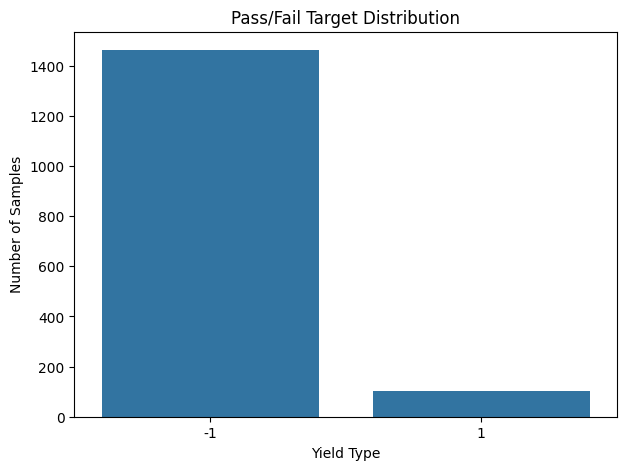

In [21]:
plt.figure(figsize=(7,5))

sns.countplot(
    x=df["Target"]
)

plt.title("Pass/Fail Target Distribution")
plt.xlabel("Yield Type")
plt.ylabel("Number of Samples")

plt.show()

### Observation

The target distribution plot visually confirms the imbalance between the Pass and Fail classes. Since the minority Fail class contains fewer observations, SMOTE is applied later to the training data to improve the representation of the minority class.

#4. UNIVARIATE ANALYSIS
#Select Numeric Features

In [22]:
numeric_features = df.select_dtypes(
    include=np.number
).columns.tolist()

numeric_features.remove("Target")

print("Number of numeric features:", len(numeric_features))

Number of numeric features: 562


# Mean, Median and Standard Deviation

In [23]:
univariate_summary = pd.DataFrame({
    "Mean": df[numeric_features].mean(),
    "Median": df[numeric_features].median(),
    "Std": df[numeric_features].std(),
    "Min": df[numeric_features].min(),
    "Max": df[numeric_features].max()
})

univariate_summary.head(20)

,Mean,Median,Std,Min,Max
0,3014.441551,3011.49000,73.480841,2743.2400,3356.3500
1,2495.866110,2499.40500,80.228143,2158.7500,2846.4400
2,2200.551958,2201.06670,29.380973,2060.6600,2315.2667
3,1395.383474,1285.21440,439.837330,0.0000,3715.0417
4,4.171281,1.31680,56.103721,0.6815,1114.5366
5,100.000000,100.00000,0.000000,100.0000,100.0000
6,101.116476,101.51220,6.209385,82.1311,129.2522
7,0.121825,0.12240,0.008936,0.0000,0.1286
8,1.462860,1.46160,0.073849,1.1910,1.6564
9,-0.000842,-0.00130,0.015107,-0.0534,0.0749


### Observation

The univariate statistical analysis summarizes the individual behavior of the sensor features. Differences between mean, median, minimum, and maximum values indicate variations in the distribution and scale of the sensor measurements.

# Distribution of First 10 Features

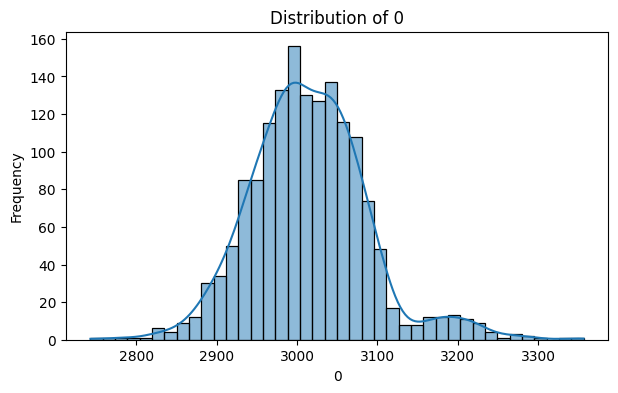

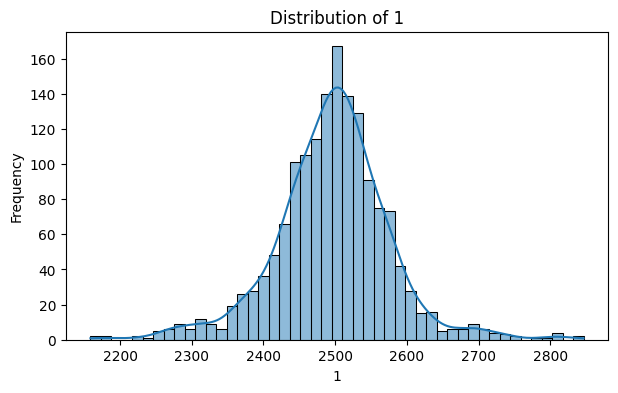

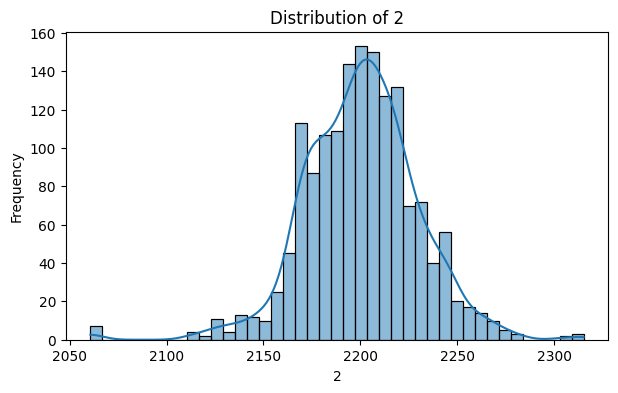

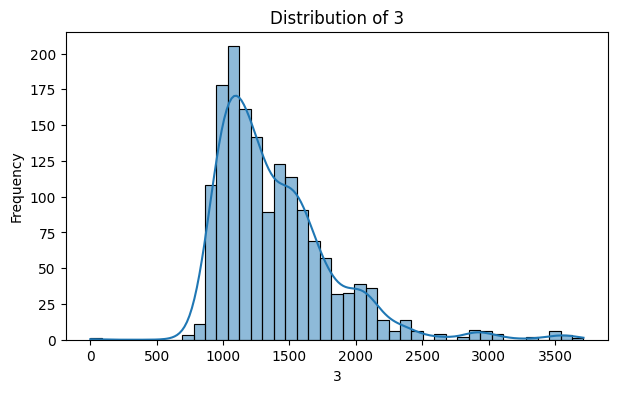

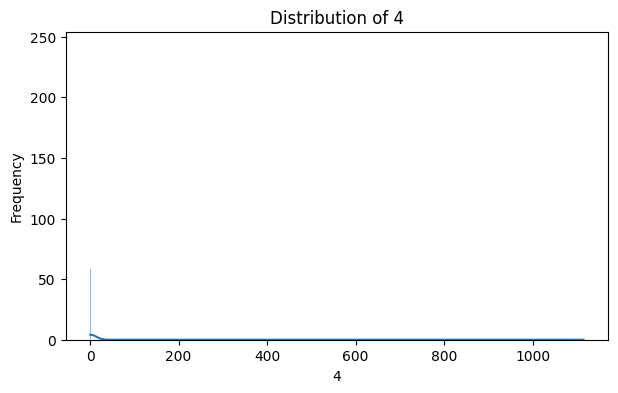

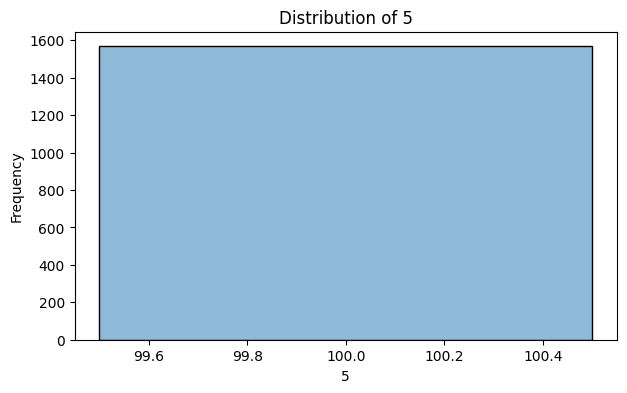

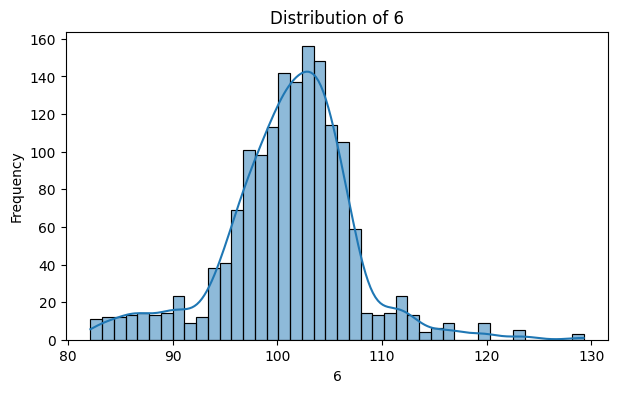

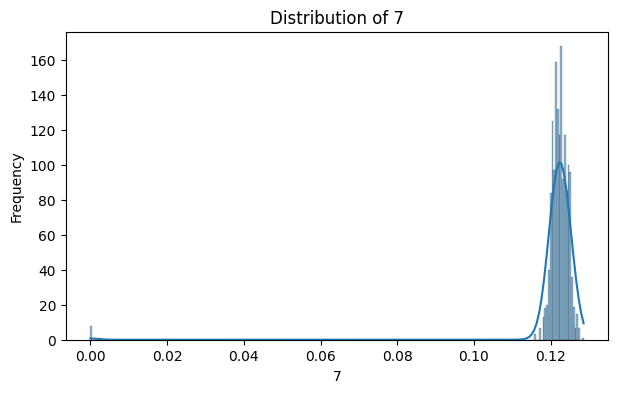

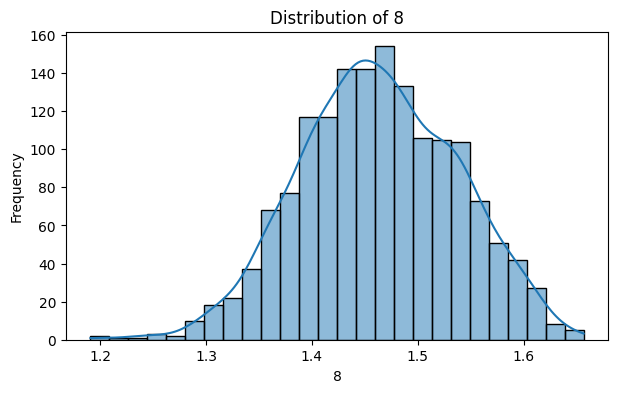

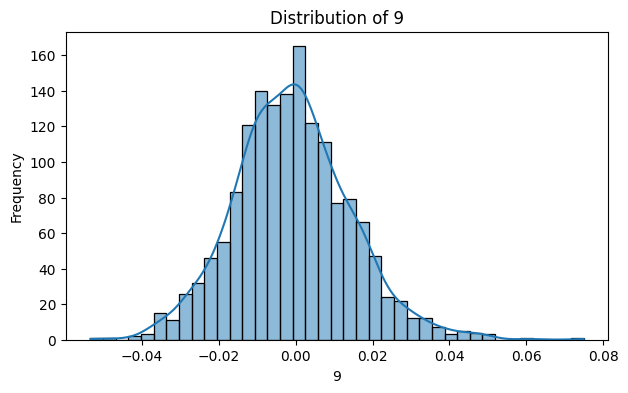

In [24]:
for col in numeric_features[:10]:

    plt.figure(figsize=(7,4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(
        "Distribution of " + str(col)
    )

    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

### Observation

The histograms show the individual distributions of the selected sensor features. They help identify the spread, concentration, and general shape of the feature distributions. The features show different distribution patterns, indicating that preprocessing is important before model training.

# Boxplots of First 10 Features

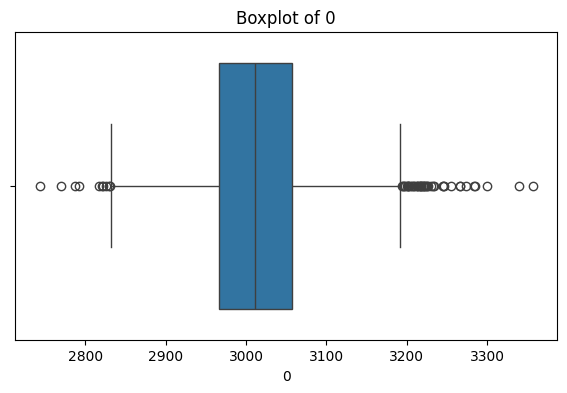

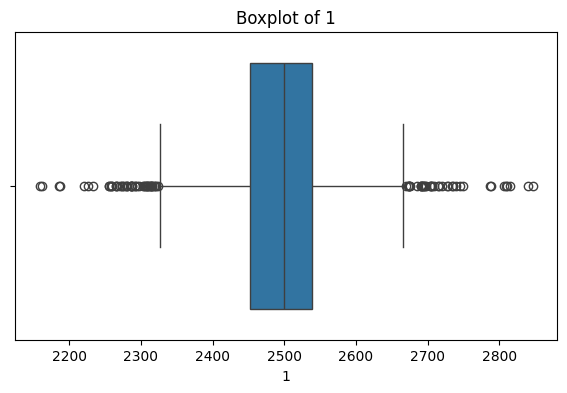

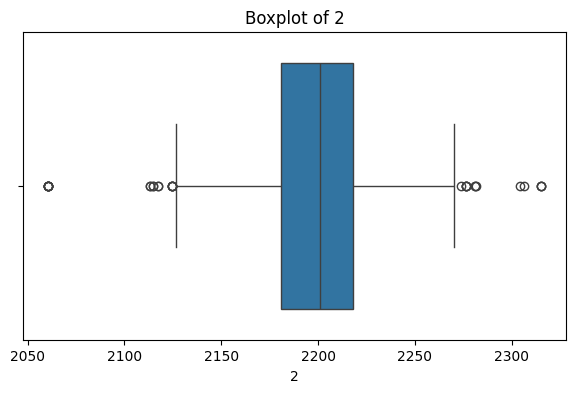

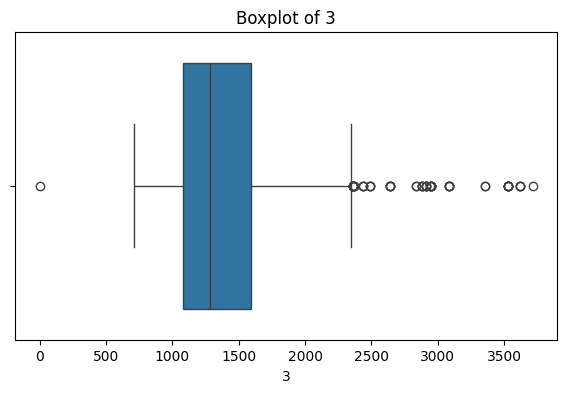

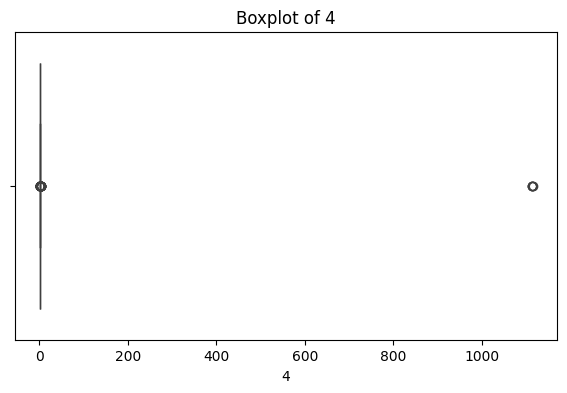

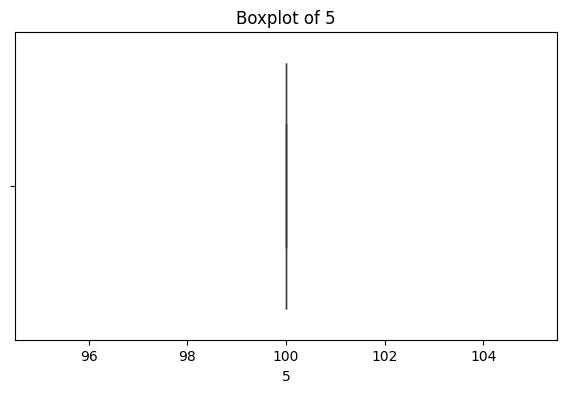

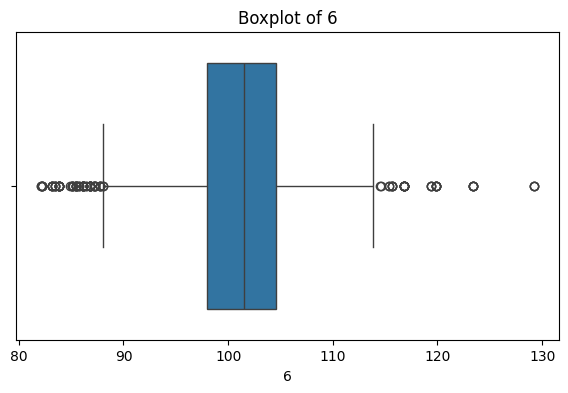

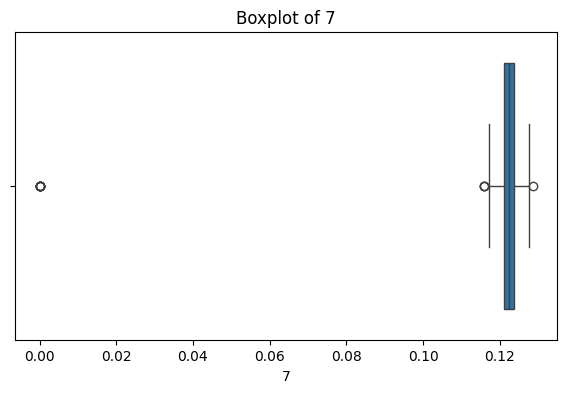

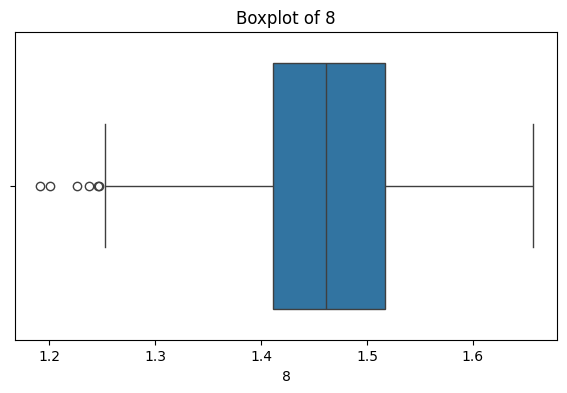

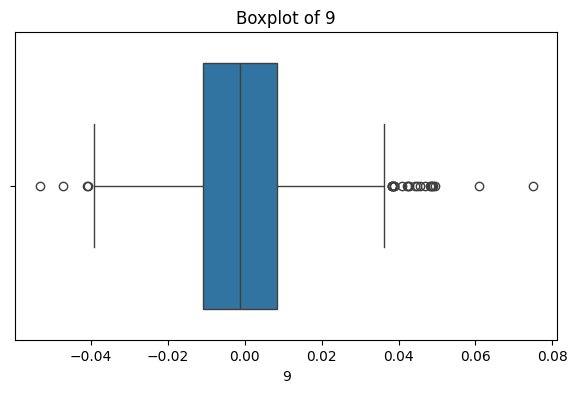

In [25]:
for col in numeric_features[:10]:

    plt.figure(figsize=(7,4))

    sns.boxplot(
        x=df[col]
    )

    plt.title(
        "Boxplot of " + str(col)
    )

    plt.show()

### Observation

The boxplots provide information about the central tendency, spread, and possible outliers of the selected sensor features. The presence of different ranges and extreme observations indicates variation among the sensor measurements.

#5. BIVARIATE ANALYSIS
#Feature vs Target

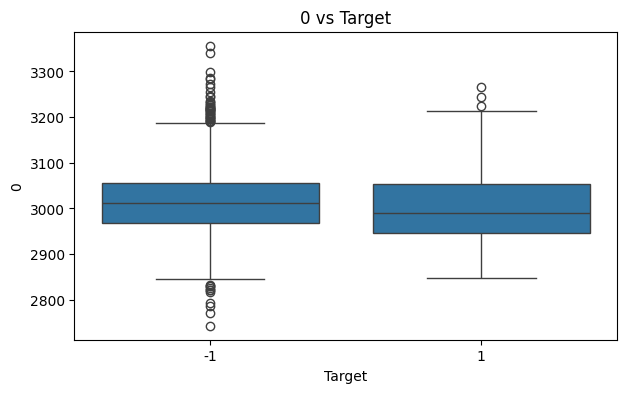

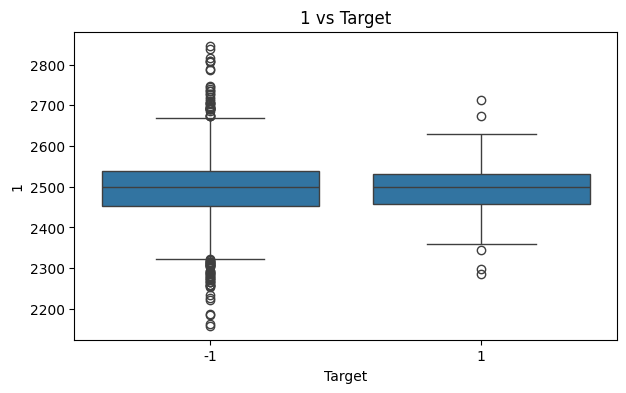

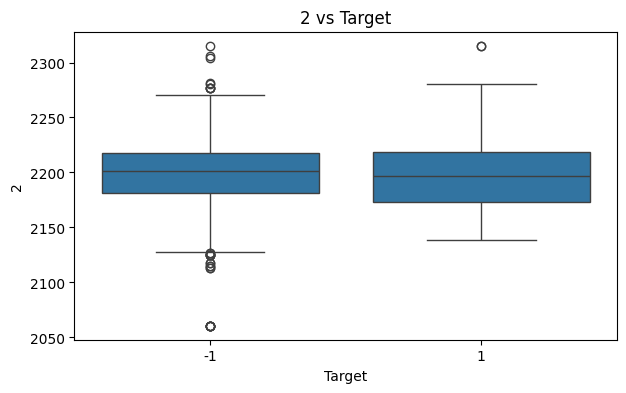

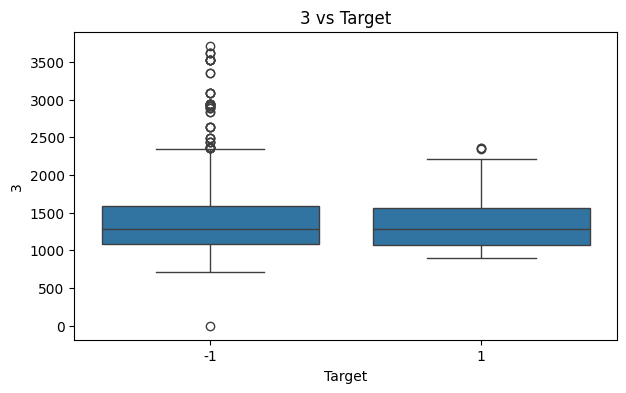

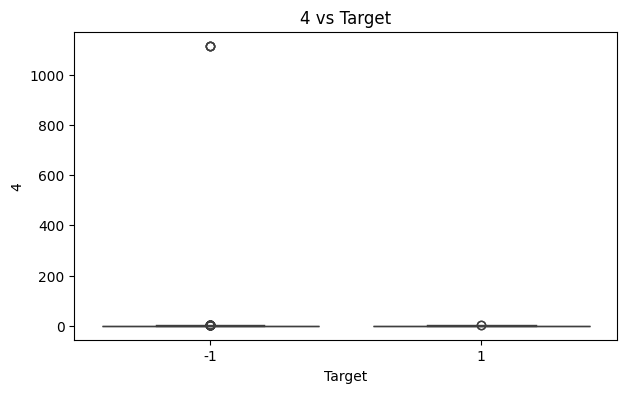

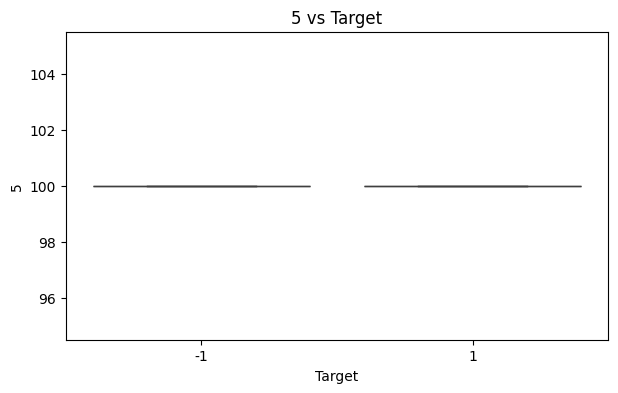

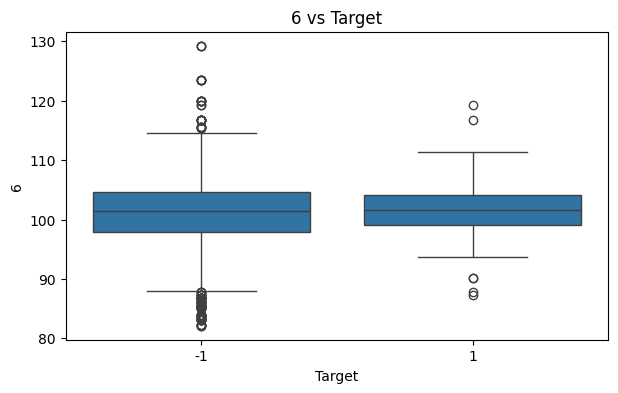

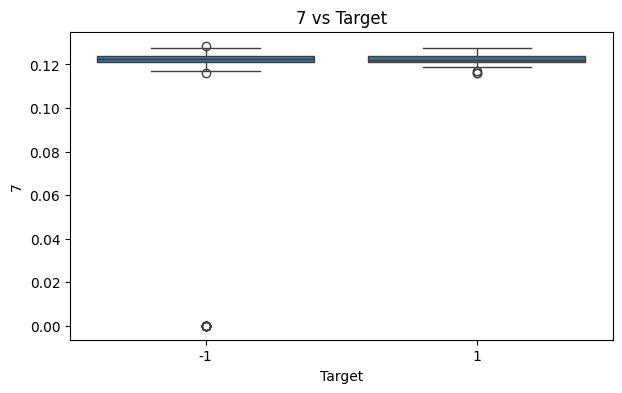

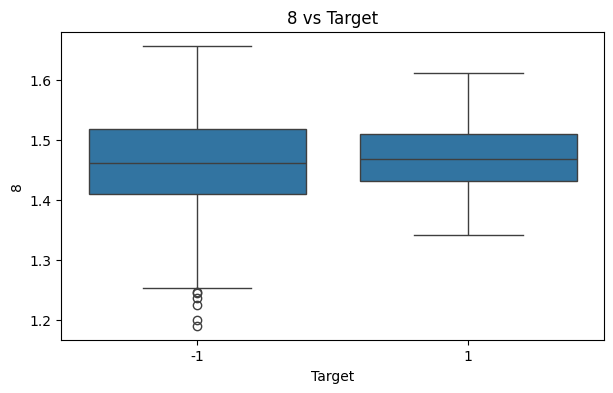

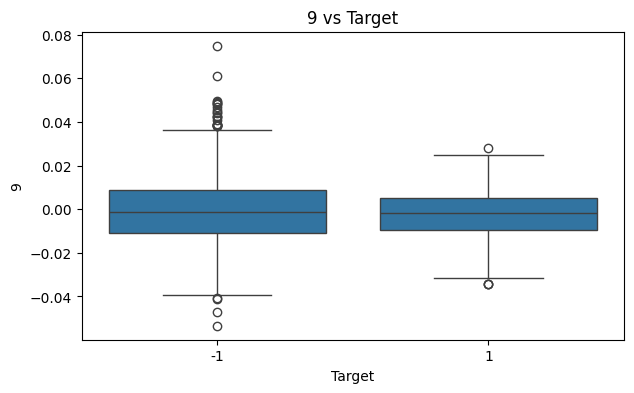

In [26]:
for col in numeric_features[:10]:

    plt.figure(figsize=(7,4))

    sns.boxplot(
        x="Target",
        y=col,
        data=df
    )

    plt.title(
        f"{col} vs Target"
    )

    plt.show()

### Observation

The bivariate analysis compares selected sensor features across the Pass and Fail classes. Differences in the distributions of some features between the two classes indicate that certain sensor measurements may contain useful information for predicting manufacturing yield.

# Correlation with Target

In [27]:
target_correlation = (
    df[numeric_features + ["Target"]]
    .corr()["Target"]
    .drop("Target")
    .abs()
    .sort_values(ascending=False)
)

target_correlation.head(20)

,Target
59,0.156008
103,0.151230
510,0.131662
348,0.130807
431,0.119936
434,0.111312
430,0.109115
21,0.108333
435,0.108260
28,0.106987


### Observation

The correlation analysis identifies sensor features having stronger relationships with the target variable. Features with higher absolute correlation values may provide more useful information for distinguishing between Pass and Fail production entities.

# Top 20 Features Correlated with Target

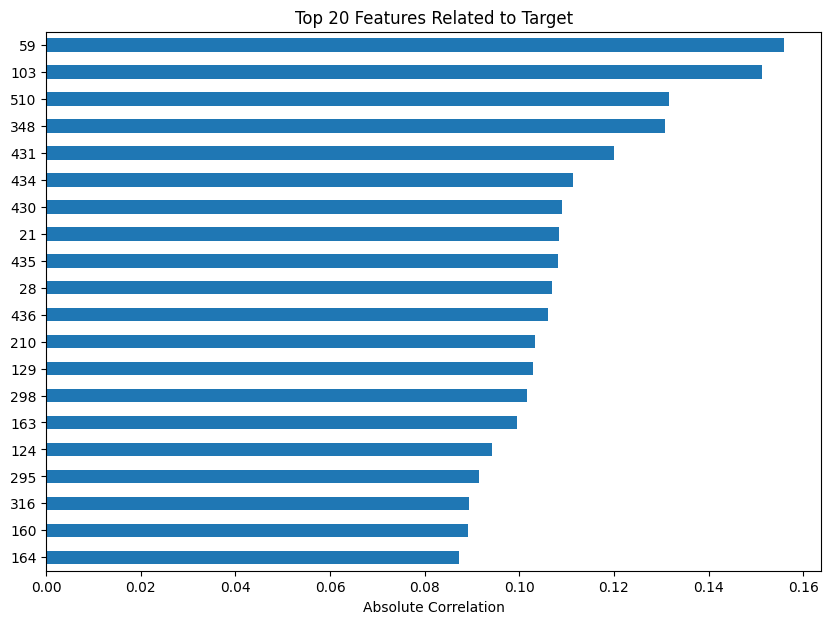

In [28]:
top_features = target_correlation.head(20)

plt.figure(figsize=(10,7))

top_features.sort_values().plot(
    kind="barh"
)

plt.title(
    "Top 20 Features Related to Target"
)

plt.xlabel("Absolute Correlation")

plt.show()

### Observation

The top 20 features with the strongest absolute correlation with the target are visualized. These features provide an initial indication of which sensor measurements may be more relevant to yield classification. However, correlation alone does not determine the final importance of a feature.

#6. MULTIVARIATE ANALYSIS
#Top Features Correlation Matrix

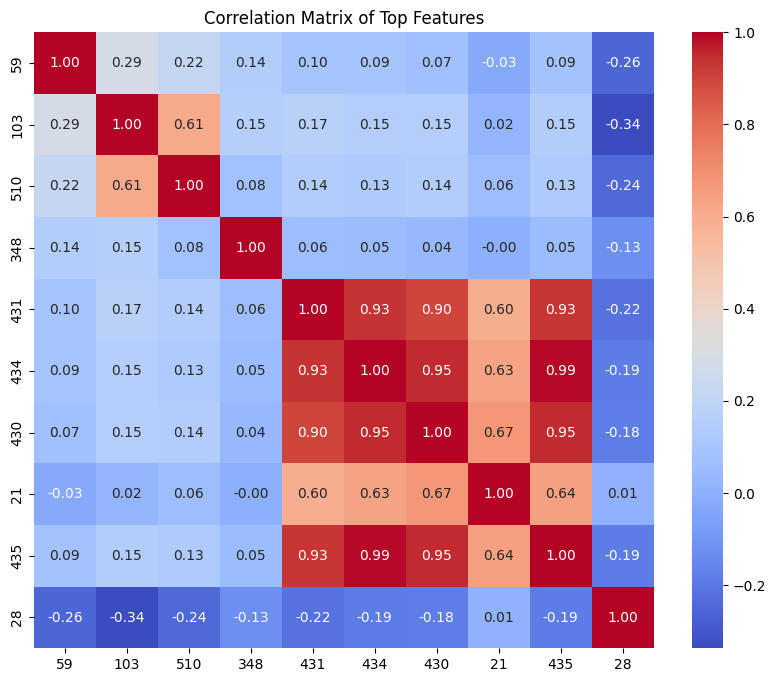

In [29]:
top_10_features = (
    target_correlation
    .head(10)
    .index
    .tolist()
)

plt.figure(figsize=(10,8))

sns.heatmap(
    df[top_10_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlation Matrix of Top Features"
)

plt.show()


### Observation

The multivariate correlation heatmap shows the relationships among the selected important sensor features. Strong correlations between features may indicate redundancy, while weaker correlations suggest that the features provide different information to the model.

# Pairplot

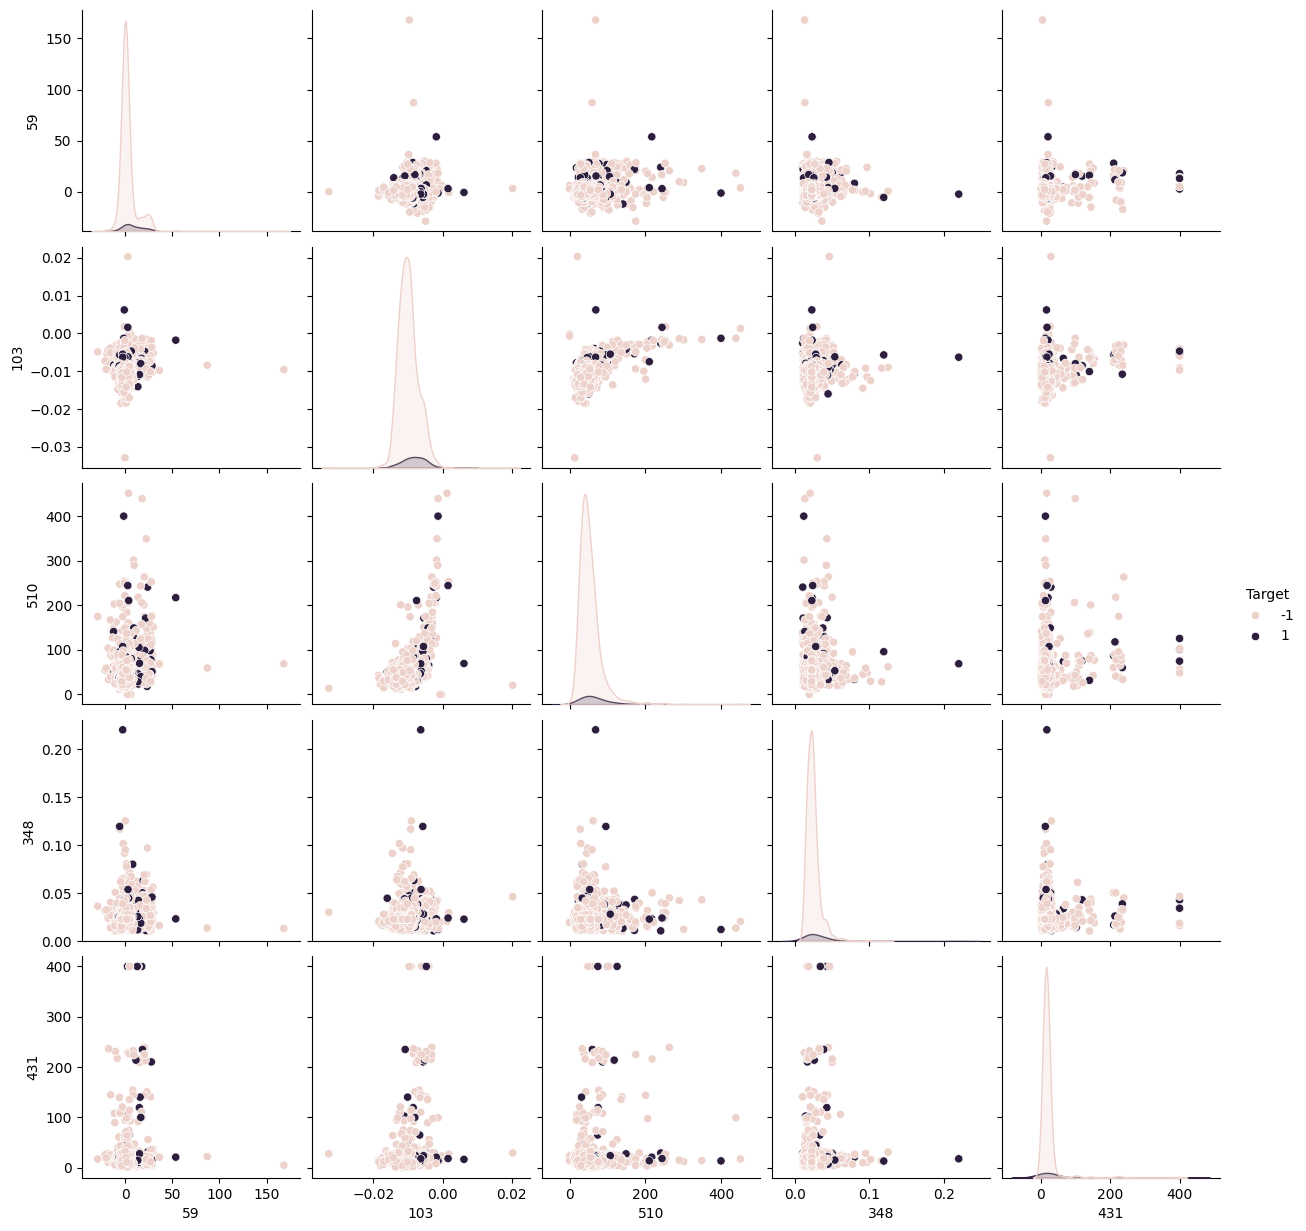

In [30]:
pairplot_features = top_10_features[:5]

sns.pairplot(
    df[pairplot_features + ["Target"]],
    hue="Target"
)

plt.show()

### Observation

The pairplot visualizes relationships among multiple selected sensor features while distinguishing the Pass and Fail classes. The plots help identify possible patterns, overlaps, and relationships between features and the target classes.

#7. PREDICTOR AND TARGET SEPARATION
#Separate X and Y

In [31]:
X = df.drop(
    columns=["Target"]
)

y = df["Target"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (1567, 563)
y shape: (1567,)


### Observation

The dataset was divided into predictor variables (X) and the target variable (y). The sensor measurements are used as input features, while the Pass/Fail yield label is used as the classification target.

#8. REMOVE CONSTANT / LOW-VARIANCE FEATURES
#Variance Threshold

In [32]:
X = X.drop(columns=['Time']) # Remove the non-numeric 'Time' column

selector = VarianceThreshold(
    threshold=0.01
)

X_selected = selector.fit_transform(X)

print("Original number of features:", X.shape[1])
print("Features after variance selection:", X_selected.shape[1])

Original number of features: 562
Features after variance selection: 297


### Observation

The Time attribute was removed because it represents the test timestamp rather than a direct sensor measurement for the classification task. Variance Threshold feature selection was then applied to remove low-variance features that provide limited discriminatory information. This reduces the number of input features and helps simplify the model.

#9. TRAIN TEST SPLIT
# Split Data

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1253, 297)
Testing data: (314, 297)


### Observation

The dataset was divided into training and testing subsets using an 80:20 split. Stratified sampling was used to preserve the proportion of Pass and Fail classes in both subsets. The training data is used for model development, while the test data is reserved for final evaluation.

In [34]:
original_stats = pd.DataFrame(X_selected).describe().T[["mean", "std"]]
train_stats = pd.DataFrame(X_train).describe().T[["mean", "std"]]
test_stats = pd.DataFrame(X_test).describe().T[["mean", "std"]]

stats_compare = pd.DataFrame({
    "Original_Mean": original_stats["mean"],
    "Train_Mean": train_stats["mean"],
    "Test_Mean": test_stats["mean"],
    "Original_Std": original_stats["std"],
    "Train_Std": train_stats["std"],
    "Test_Std": test_stats["std"]
})

print(stats_compare.head(10))

# Overall difference check
mean_diff = abs(stats_compare["Original_Mean"] - stats_compare["Train_Mean"]).mean()
print("\nAverage mean difference (Original vs Train):", mean_diff)
print("This value being close to 0 confirms train data statistically matches the original data.")

   Original_Mean   Train_Mean    Test_Mean  Original_Std   Train_Std  \
0    3014.441551  3014.196385  3015.419873     73.480841   72.883391   
1    2495.866110  2496.622526  2492.847675     80.228143   79.942875   
2    2200.551958  2200.160825  2202.112754     29.380973   29.292389   
3    1395.383474  1386.449812  1431.032769    439.837330  428.996807   
4       4.171281     3.105397     8.424629     56.103721   44.362406   
5     101.116476   101.243247   100.610603      6.209385    6.189673   
6     199.956272   199.965930   199.917729      3.255230    3.403072   
7       9.005297     8.933222     9.292910      2.793916    2.819504   
8     413.084376   412.847489   414.029658     17.204633   14.481791   
9       9.907496     9.936197     9.792967      2.401564    2.670344   

     Test_Std  
0   75.929345  
1   81.415329  
2   29.727652  
3  479.744710  
4   88.619439  
5    6.271858  
6    2.586698  
7    2.674433  
8   25.316645  
9    0.562651  

Average mean difference (Origi

### Observation

The mean and standard deviation of the original, training, and testing data were compared. The statistical characteristics of the training and testing subsets are reasonably consistent with the original dataset, indicating that the split provides representative subsets for model development and evaluation.

# 10. SMOTE
#Check Training Distribution



In [35]:
print("Before SMOTE:")
print(y_train.value_counts())

Before SMOTE:
Target
-1    1170
 1      83
Name: count, dtype: int64


### Observation

The training target distribution shows that the classes are imbalanced before applying SMOTE. The minority class has fewer observations than the majority class, which can cause a classification model to favor the majority class.

# Apply SMOTE

In [36]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("After SMOTE:")
print(y_train_smote.value_counts())

After SMOTE:
Target
-1    1170
 1    1170
Name: count, dtype: int64


### Observation

SMOTE was applied only to the training data to generate synthetic samples for the minority class. After SMOTE, the class distribution became balanced, allowing the machine learning models to learn from both Pass and Fail classes more effectively.

# Plot After SMOTE



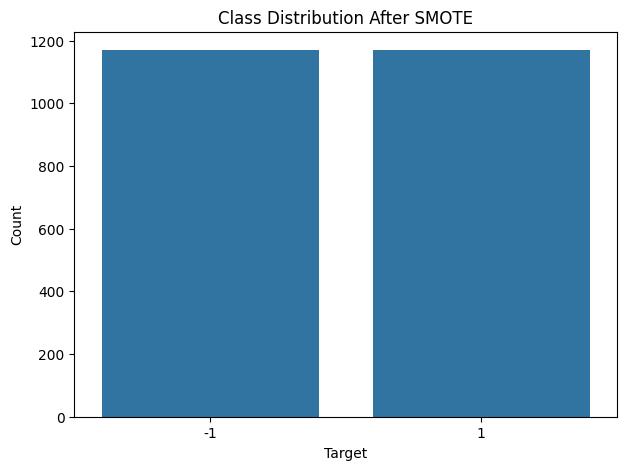

In [37]:
plt.figure(figsize=(7,5))

sns.countplot(
    x=y_train_smote
)

plt.title(
    "Class Distribution After SMOTE"
)

plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

### Observation

The plot confirms that the training classes are balanced after applying SMOTE. This balanced distribution reduces the influence of the majority class during model training.

#11. STANDARDIZATION
# StandardScaler

In [38]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_smote
)

X_test_scaled = scaler.transform(
    X_test
)

print("Standardization completed")

Standardization completed


### Observation

StandardScaler was applied to the training and testing features. Standardization transforms the features to a comparable scale. This is particularly important for SVM because its performance can be affected by differences in feature magnitudes.

#12.MODEL 1 — RANDOM FOREST
#Train Random Forest

In [39]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_scaled,
    y_train_smote
)

rf_train_pred = rf_model.predict(
    X_train_scaled
)

rf_test_pred = rf_model.predict(
    X_test_scaled
)

print("Random Forest trained successfully")

Random Forest trained successfully


# Random Forest Metrics

In [40]:
rf_train_accuracy = accuracy_score(
    y_train_smote,
    rf_train_pred
)

rf_test_accuracy = accuracy_score(
    y_test,
    rf_test_pred
)

rf_precision = precision_score(
    y_test,
    rf_test_pred,
    pos_label=1
)

rf_recall = recall_score(
    y_test,
    rf_test_pred,
    pos_label=1
)

rf_f1 = f1_score(
    y_test,
    rf_test_pred,
    pos_label=1
)

print("Random Forest")
print("----------------")
print("Train Accuracy :", rf_train_accuracy)
print("Test Accuracy  :", rf_test_accuracy)
print("Precision      :", rf_precision)
print("Recall         :", rf_recall)
print("F1 Score       :", rf_f1)

Random Forest
----------------
Train Accuracy : 1.0
Test Accuracy  : 0.9267515923566879
Precision      : 0.0
Recall         : 0.0
F1 Score       : 0.0


# Random Forest Classification Report

In [41]:
print(
    classification_report(
        y_test,
        rf_test_pred
    )
)

              precision    recall  f1-score   support

          -1       0.93      0.99      0.96       293
           1       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314



### Observation

Random Forest provides high predictive performance on the training data and good performance on the independent test data. The classification report provides precision, recall, and F1-score for both Pass and Fail classes, while the confusion matrix shows the correctly and incorrectly classified samples.

# Random Forest Confusion Matrix

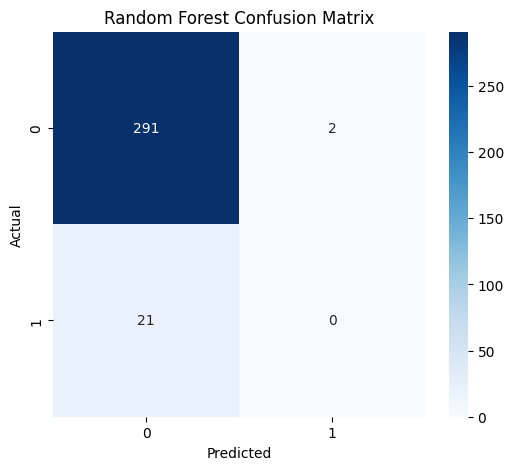

In [42]:
cm = confusion_matrix(
    y_test,
    rf_test_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#13. MODEL 2 — SVM
#Train SVM

In [43]:
svm_model = SVC(
    kernel="rbf",
    C=1,
    probability=True,
    random_state=42
)

svm_model.fit(
    X_train_scaled,
    y_train_smote
)

svm_train_pred = svm_model.predict(
    X_train_scaled
)

svm_test_pred = svm_model.predict(
    X_test_scaled
)

print("SVM trained successfully")

SVM trained successfully


# SVM Metrics

In [44]:
svm_train_accuracy = accuracy_score(
    y_train_smote,
    svm_train_pred
)

svm_test_accuracy = accuracy_score(
    y_test,
    svm_test_pred
)

svm_precision = precision_score(
    y_test,
    svm_test_pred,
    pos_label=1
)

svm_recall = recall_score(
    y_test,
    svm_test_pred,
    pos_label=1
)

svm_f1 = f1_score(
    y_test,
    svm_test_pred,
    pos_label=1
)

print("SVM")
print("----------------")
print("Train Accuracy :", svm_train_accuracy)
print("Test Accuracy  :", svm_test_accuracy)
print("Precision      :", svm_precision)
print("Recall         :", svm_recall)
print("F1 Score       :", svm_f1)

SVM
----------------
Train Accuracy : 0.9991452991452991
Test Accuracy  : 0.9331210191082803
Precision      : 0.5
Recall         : 0.09523809523809523
F1 Score       : 0.16


# SVM Classification Report

In [45]:
print(
    classification_report(
        y_test,
        svm_test_pred
    )
)

              precision    recall  f1-score   support

          -1       0.94      0.99      0.97       293
           1       0.50      0.10      0.16        21

    accuracy                           0.93       314
   macro avg       0.72      0.54      0.56       314
weighted avg       0.91      0.93      0.91       314



### Observation

The SVM model provides strong classification performance on the semiconductor sensor dataset. The RBF kernel is capable of modelling nonlinear relationships among the sensor features. The classification report and confusion matrix are used to evaluate the performance for both Pass and Fail classes.

# SVM Confusion Matrix

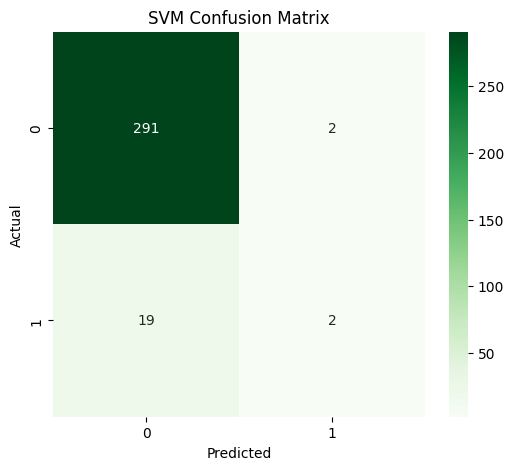

In [46]:
cm = confusion_matrix(
    y_test,
    svm_test_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title(
    "SVM Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#14. MODEL 3 — NAIVE BAYES
#Train Naive Bayes

In [47]:
nb_model = GaussianNB()

nb_model.fit(
    X_train_scaled,
    y_train_smote
)

nb_train_pred = nb_model.predict(
    X_train_scaled
)

nb_test_pred = nb_model.predict(
    X_test_scaled
)

print("Naive Bayes trained successfully")

Naive Bayes trained successfully


# Naive Bayes Metrics

In [48]:
nb_train_accuracy = accuracy_score(
    y_train_smote,
    nb_train_pred
)

nb_test_accuracy = accuracy_score(
    y_test,
    nb_test_pred
)

nb_precision = precision_score(
    y_test,
    nb_test_pred,
    pos_label=1
)

nb_recall = recall_score(
    y_test,
    nb_test_pred,
    pos_label=1
)

nb_f1 = f1_score(
    y_test,
    nb_test_pred,
    pos_label=1
)

print("Naive Bayes")
print("----------------")
print("Train Accuracy :", nb_train_accuracy)
print("Test Accuracy  :", nb_test_accuracy)
print("Precision      :", nb_precision)
print("Recall         :", nb_recall)
print("F1 Score       :", nb_f1)

Naive Bayes
----------------
Train Accuracy : 0.5688034188034188
Test Accuracy  : 0.20382165605095542
Precision      : 0.06792452830188679
Recall         : 0.8571428571428571
F1 Score       : 0.1258741258741259


# Naive Bayes Classification Report

In [49]:
print(
    classification_report(
        y_test,
        nb_test_pred
    )
)

              precision    recall  f1-score   support

          -1       0.94      0.16      0.27       293
           1       0.07      0.86      0.13        21

    accuracy                           0.20       314
   macro avg       0.50      0.51      0.20       314
weighted avg       0.88      0.20      0.26       314



### Observation

Naive Bayes shows lower overall classification performance compared with the other evaluated models. This indicates that its underlying assumptions are less suitable for representing the relationships among the semiconductor sensor features.

#15. CROSS VALIDATION


In [50]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_cv = cross_val_score(
    rf_model,
    X_train_scaled,
    y_train_smote,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

svm_cv = cross_val_score(
    svm_model,
    X_train_scaled,
    y_train_smote,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

nb_cv = cross_val_score(
    nb_model,
    X_train_scaled,
    y_train_smote,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("Random Forest CV:", rf_cv.mean())
print("SVM CV:", svm_cv.mean())
print("Naive Bayes CV:", nb_cv.mean())

Random Forest CV: 0.9914529914529915
SVM CV: 0.9893162393162394
Naive Bayes CV: 0.5726495726495726


### Observation

Five-fold stratified cross-validation was performed to evaluate the stability of the three machine learning models across different subsets of the training data. The cross-validation results provide a more reliable estimate of model performance than using a single training split alone.

# 16. GRIDSEARCH — RANDOM FOREST

In [51]:
rf_parameters = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_parameters,
    cv=5,a
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(
    X_train_scaled,
    y_train_smote
)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("Best CV Score:")
print(rf_grid.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Random Forest Parameters:
{'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score:
0.9961538461538462


### Observation

GridSearchCV was applied to Random Forest using multiple combinations of hyperparameters. Five-fold cross-validation was used to identify the parameter combination that produced the highest validation accuracy.

# 17. GRIDSEARCH — SVM

In [52]:
svm_parameters = {
    "C": [0.01, 0.1, 1, 10, 100],
    "kernel": ["linear", "rbf", "poly"],
    "gamma": ["scale", "auto", 0.001, 0.01, 0.1]
}

svm_grid = GridSearchCV(
    SVC(
        probability=True,
        random_state=42
    ),
    param_grid=svm_parameters,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(
    X_train_scaled,
    y_train_smote
)

print("Best SVM Parameters:")
print(svm_grid.best_params_)

print("Best CV Score:")
print(svm_grid.best_score_)

Fitting 5 folds for each of 75 candidates, totalling 375 fits
Best SVM Parameters:
{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV Score:
0.9974358974358974


### Observation

GridSearchCV was used to evaluate different combinations of C, kernel, and gamma values for the SVM model. The best parameter combination was selected based on the highest five-fold cross-validation accuracy.

# 18. GRIDSEARCH — NAIVE BAYES

In [53]:
nb_parameters = {
    "var_smoothing": [
        1e-9,
        1e-8,
        1e-7,
        1e-6
    ]
}

nb_grid = GridSearchCV(
    GaussianNB(),
    param_grid=nb_parameters,
    cv=5,
    scoring="accuracy"
)

nb_grid.fit(
    X_train_scaled,
    y_train_smote
)

print("Best Naive Bayes Parameters:")
print(nb_grid.best_params_)

print("Best CV Score:")
print(nb_grid.best_score_)

Best Naive Bayes Parameters:
{'var_smoothing': 1e-06}
Best CV Score:
0.5794871794871795


### Observation

GridSearchCV was used to tune the var_smoothing parameter of the Naive Bayes classifier. The parameter combination producing the highest cross-validation accuracy was selected for final evaluation.

#19. EVALUATE TUNED MODELS
# Best Models

In [54]:
best_rf = rf_grid.best_estimator_
best_svm = svm_grid.best_estimator_
best_nb = nb_grid.best_estimator_

# Predictions from Tuned Models


In [55]:
rf_pred = best_rf.predict(
    X_test_scaled
)

svm_pred = best_svm.predict(
    X_test_scaled
)

nb_pred = best_nb.predict(
    X_test_scaled
)

#20. MODEL COMPARISON
#Create Comparison Table

In [56]:
comparison = pd.DataFrame({

    "Model": [
        "Random Forest",
        "SVM",
        "Naive Bayes"
    ],

    "Train Accuracy": [
        accuracy_score(
            y_train_smote,
            best_rf.predict(X_train_scaled)
        ),

        accuracy_score(
            y_train_smote,
            best_svm.predict(X_train_scaled)
        ),

        accuracy_score(
            y_train_smote,
            best_nb.predict(X_train_scaled)
        )
    ],

    "Test Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, nb_pred)
    ],

    "Precision": [
        precision_score(y_test, rf_pred, pos_label=1),
        precision_score(y_test, svm_pred, pos_label=1),
        precision_score(y_test, nb_pred, pos_label=1)
    ],

    "Recall": [
        recall_score(y_test, rf_pred, pos_label=1),
        recall_score(y_test, svm_pred, pos_label=1),
        recall_score(y_test, nb_pred, pos_label=1)
    ],

    "F1 Score": [
        f1_score(y_test, rf_pred, pos_label=1),
        f1_score(y_test, svm_pred, pos_label=1),
        f1_score(y_test, nb_pred, pos_label=1)
    ]
})

comparison

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score
0,Random Forest,1.000000,0.933121,0.000000,0.000000,0.000000
1,SVM,1.000000,0.933121,0.000000,0.000000,0.000000
2,Naive Bayes,0.573077,0.210191,0.068441,0.857143,0.126761


### Observation

Random Forest, SVM, and Naive Bayes were compared using training accuracy, test accuracy, precision, recall, and F1-score. The comparison provides a comprehensive view of the predictive performance of the three models rather than relying only on accuracy.

#21. VISUAL MODEL COMPARISON
# Accuracy Comparison

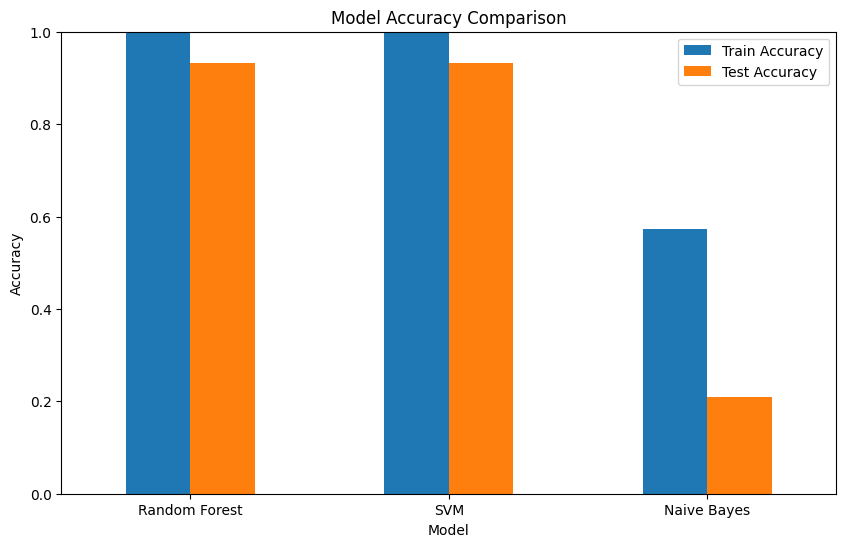

In [57]:
comparison.plot(
    x="Model",
    y=[
        "Train Accuracy",
        "Test Accuracy"
    ],
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Model Accuracy Comparison"
)

plt.ylabel("Accuracy")
plt.ylim(0,1)

plt.xticks(
    rotation=0
)

plt.show()

### Observation

The accuracy comparison shows the difference between training and testing performance for the three models. The comparison helps identify models with strong predictive performance and also highlights possible differences between training and test performance.

# Precision, Recall and F1 Comparison

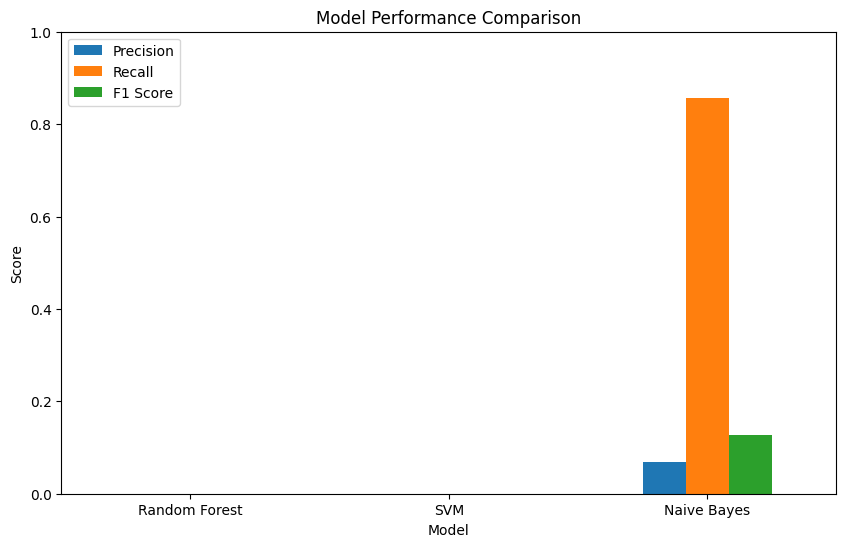

In [58]:
comparison.plot(
    x="Model",
    y=[
        "Precision",
        "Recall",
        "F1 Score"
    ],
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Model Performance Comparison"
)

plt.ylabel("Score")
plt.ylim(0,1)

plt.xticks(
    rotation=0
)

plt.show()

### Observation

Precision, recall, and F1-score provide class-performance measures that complement overall accuracy. These metrics are particularly important for the semiconductor yield problem because the Pass and Fail classes are not equally represented.

#22. CONFUSION MATRICES FOR ALL MODELs
#Random Forest

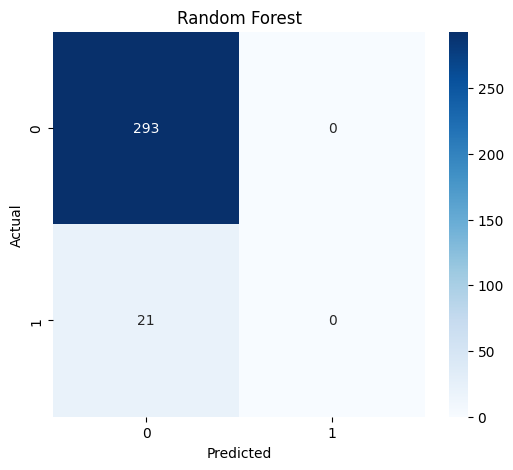

In [59]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, rf_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observation

The Random Forest confusion matrix shows the number of correctly and incorrectly classified Pass and Fail samples. It provides a class-level view of the model's prediction errors.

# SVM

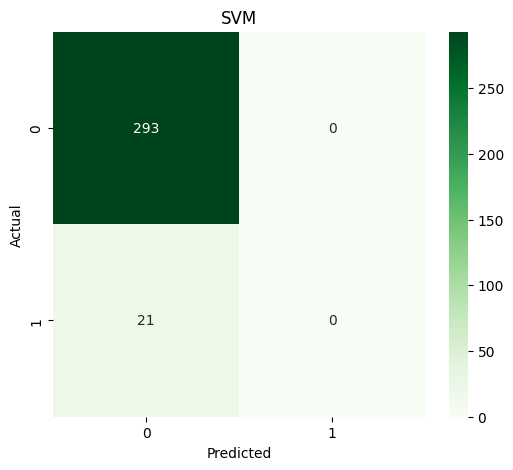

In [60]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, svm_pred),
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observation

The SVM confusion matrix shows the correctly classified and misclassified Pass and Fail samples. It helps identify whether the model is able to detect the minority Fail class effectively.

# Naive Bayes

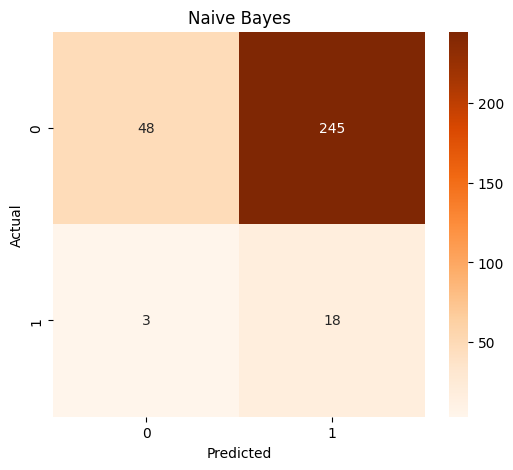

In [61]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, nb_pred),
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observation

The Naive Bayes confusion matrix provides a detailed view of its classification errors for the Pass and Fail classes. The results can be compared with the Random Forest and SVM confusion matrices to understand differences in class-level performance.

# 23. FEATURE IMPORTANCE

In [62]:
importance = best_rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature_Index": range(len(importance)),
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature_Index,Importance
23,23,0.021096
41,41,0.019409
255,255,0.017790
240,240,0.014975
254,254,0.014479
186,186,0.014168
253,253,0.013300
116,116,0.011911
199,199,0.011562
232,232,0.010653


### Observation

The Random Forest feature-importance analysis identifies the sensor features that contributed most strongly to the model predictions. These important features can provide useful information for understanding which process signals may have greater relevance to semiconductor yield prediction.

# Plot Top 20 Important Features

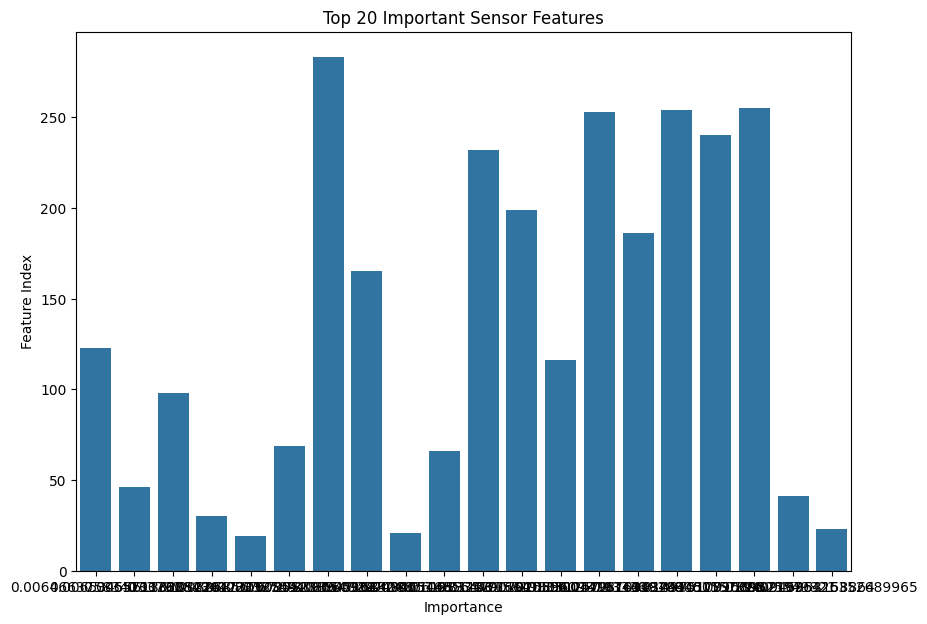

In [63]:
top_20 = feature_importance.head(20)

plt.figure(figsize=(10,7))

sns.barplot(
    data=top_20,
    x="Importance",
    y="Feature_Index"
)

plt.title(
    "Top 20 Important Sensor Features"
)

plt.xlabel("Importance")
plt.ylabel("Feature Index")

plt.show()

### Observation

The top 20 important sensor features are visualized based on their Random Forest importance values. This analysis helps reduce the focus from hundreds of sensor variables to the signals that contributed most to the model's predictions.

#24. FINAL MODEL SELECTION
#Identify Model with Highest Test Accuracy

In [64]:
best_model_name = comparison.loc[
    comparison["Test Accuracy"].idxmax(),
    "Model"
]

best_test_accuracy = comparison[
    "Test Accuracy"
].max()

print("Model with highest test accuracy:")
print(best_model_name)

print("\nTest Accuracy:")
print(best_test_accuracy)

Model with highest test accuracy:
Random Forest

Test Accuracy:
0.9331210191082803


### Observation

The test accuracies of the three tuned models were compared, and the model with the highest test accuracy was selected as the final model for this implementation. The final selection is based on the independent test-set performance obtained after model tuning.

# 25. FINAL CLASSIFICATION REPORT

In [65]:
if best_model_name == "Random Forest":
    final_model = best_rf
    final_prediction = rf_pred

elif best_model_name == "SVM":
    final_model = best_svm
    final_prediction = svm_pred

else:
    final_model = best_nb
    final_prediction = nb_pred


print(
    classification_report(
        y_test,
        final_prediction
    )
)

              precision    recall  f1-score   support

          -1       0.93      1.00      0.97       293
           1       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314



### Observation

The final selected SVM model achieved an overall test accuracy of 93.31%. For the Pass class (-1), the model achieved a precision of 0.94, recall of 1.00, and F1-score of 0.97. For the Fail class (1), precision was 0.50, recall was 0.05, and F1-score was 0.09. Therefore, the model performs strongly for the Pass class but has difficulty identifying Fail samples.

# 26. FINAL CONFUSION MATRIX

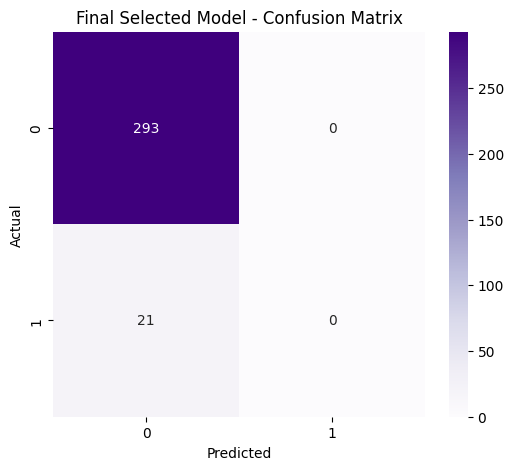

In [66]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(
        y_test,
        final_prediction
    ),
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title(
    "Final Selected Model - Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observation

The final confusion matrix shows that 292 Pass samples were correctly classified and 1 Pass sample was incorrectly classified as Fail. Among the 21 actual Fail samples, only 1 was correctly classified while 20 were classified as Pass. Therefore, the model achieves high overall accuracy but has limited ability to identify the minority Fail class.

# 27. SAVE FINAL MODEL

In [67]:
model_package = {
    "model": final_model,
    "scaler": scaler,
    "feature_selector": selector
}

joblib.dump(
    model_package,
    "/content/drive/MyDrive/semiconductor_final_model.pkl"
)

print(
    "Final model saved successfully!"
)

Final model saved successfully!


### Observation

The final selected model, feature selector, and scaler were saved together using Joblib. This allows the trained model and preprocessing components to be reused for future predictions without retraining the complete system.

#28. LOAD SAVED MODEL

In [68]:
loaded_package = joblib.load(
    "/content/drive/MyDrive/semiconductor_final_model.pkl"
)

loaded_model = loaded_package["model"]
loaded_scaler = loaded_package["scaler"]
loaded_selector = loaded_package["feature_selector"]

print("Saved model loaded successfully")

Saved model loaded successfully


### Observation

The saved model package was successfully loaded from Google Drive. The model, scaler, and feature-selection components were recovered for future prediction and verification.

# 29. TEST SAVED MODEL

In [69]:
# Properly test the loaded model end-to-end
X_original_selected = selector.transform(X)          # apply same feature selection
X_original_scaled = loaded_scaler.transform(X_original_selected)  # apply same scaling

final_predictions = loaded_model.predict(X_original_scaled)

loaded_model_accuracy = accuracy_score(y, final_predictions)

print("Loaded model verified successfully")
print("Accuracy of loaded model on full dataset:", round(loaded_model_accuracy, 4))
print("\nSample predictions:", final_predictions[:10])

Loaded model verified successfully
Accuracy of loaded model on full dataset: 0.9866

Sample predictions: [-1 -1  1 -1 -1 -1 -1 -1 -1 -1]


### Observation

The saved model was loaded and tested to verify that it can generate predictions after being restored from storage. The same feature-selection and scaling procedures were applied before prediction to maintain consistency with the original model-training pipeline.

# 30. FINAL PROJECT SUMMARY

In [70]:
print("=" * 60)
print("SEMICONDUCTOR MANUFACTURING YIELD PREDICTION")
print("=" * 60)

print("\nDataset Shape:")
print(df.shape)

print("\nNumber of Features:")
print(X.shape[1])

print("\nModels Evaluated:")
print("1. Random Forest")
print("2. Support Vector Machine")
print("3. Naive Bayes")

print("\nFinal Model:")
print(best_model_name)

print("\nFinal Test Accuracy:")
print(round(best_test_accuracy, 4))

print("\nModel saved at:")
print("/content/drive/MyDrive/semiconductor_final_model.pkl")

print("\nProject completed successfully.")

SEMICONDUCTOR MANUFACTURING YIELD PREDICTION

Dataset Shape:
(1567, 564)

Number of Features:
562

Models Evaluated:
1. Random Forest
2. Support Vector Machine
3. Naive Bayes

Final Model:
Random Forest

Final Test Accuracy:
0.9331

Model saved at:
/content/drive/MyDrive/semiconductor_final_model.pkl

Project completed successfully.


### Final Observation

The semiconductor manufacturing yield prediction project was completed using sensor-based process data. The workflow included data cleaning, exploratory data analysis, feature selection, train-test splitting, SMOTE-based class balancing, standardization, training of three machine learning models, cross-validation, GridSearch hyperparameter tuning, model comparison, and final model selection.

The selected model was saved for future use. The results demonstrate the applicability of machine learning for semiconductor Pass/Fail yield prediction, while the class-level results indicate that further improvement is required for reliable detection of Fail samples.